In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")

csv_path = "./migration_delays/migration_delays.csv"

df = pd.read_csv(csv_path)

df.head()

,recv_step,recv_eval,from_island,to_island,send_step,send_eval,delay_steps,delay_eval,send_timestamp,fitness
0,2,20,53,0,1,16,1,4,1.778449e+09,3657.167452
1,2,20,3,26,1,16,1,4,1.778449e+09,3507.176871
2,2,20,3,39,1,16,1,4,1.778449e+09,3775.964841
3,3,24,15,86,1,16,2,8,1.778449e+09,3872.652537
4,3,24,15,86,1,16,2,8,1.778449e+09,3599.902769


In [2]:
df["delay_eval"].describe()

count    82167.000000
mean       -87.118576
std        293.997532
min      -1440.000000
25%        -24.000000
50%          4.000000
75%         16.000000
max       1432.000000
Name: delay_eval, dtype: float64

In [3]:
df["delay_eval"].mean()

-87.11857558387187

In [4]:
df["delay_eval"].std()

293.99753169371013

<Axes: >

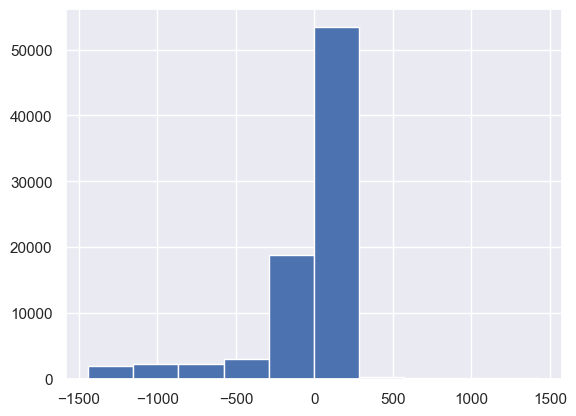

In [5]:
df["delay_eval"].hist()

In [6]:
df.groupby(["from_island", "to_island"])["delay_eval"].mean()

from_island  to_island
0            4            -10.180000
             13            -6.720000
             34           -22.793296
             52           -25.252747
             55           -21.711340
                             ...    
99           9           -721.219512
             11          -618.497238
             46          -704.334884
             78          -624.795699
             85          -713.695652
Name: delay_eval, Length: 486, dtype: float64

In [7]:
mean_delay = df.groupby("recv_step")["delay_eval"].mean()
mean_delay

recv_step
2        2.019802
3        3.315789
4        1.152104
5      -59.275168
6     -190.348228
          ...    
367     38.301370
368     71.267606
369     49.277778
370     51.565891
371     57.142857
Name: delay_eval, Length: 370, dtype: float64

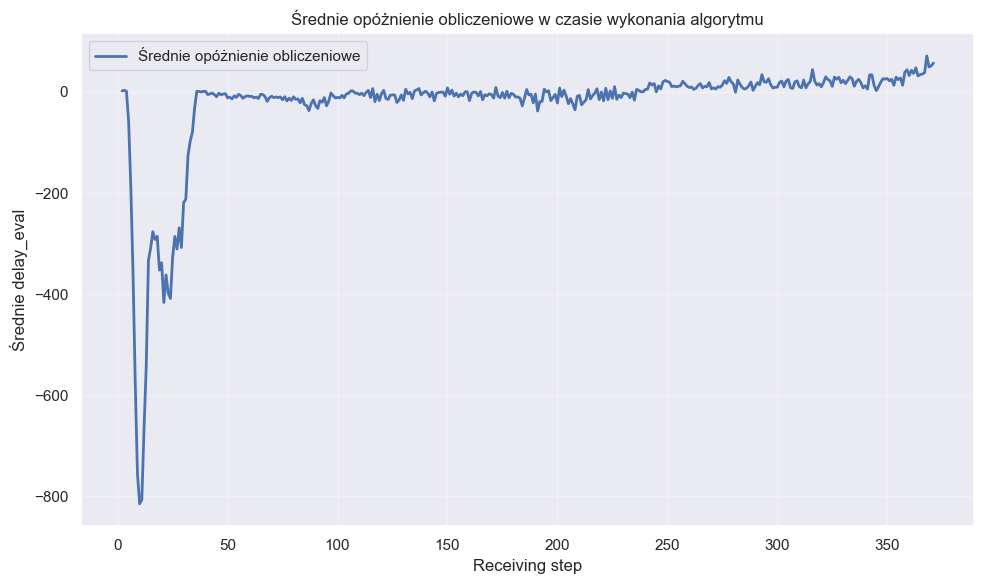

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    mean_delay.index,
    mean_delay.values,
    linewidth=2,
    label="Średnie opóżnienie obliczeniowe"
)

plt.xlabel("Receiving step")
plt.ylabel("Średnie delay_eval")
plt.title("Średnie opóżnienie obliczeniowe w czasie wykonania algorytmu")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
df["delay_eval"].quantile([0.01, 0.1, 0.5, 0.9, 0.99])

0.01   -1300.0
0.10    -396.0
0.50       4.0
0.90      32.0
0.99     148.0
Name: delay_eval, dtype: float64

In [13]:
df["delay_eval"].abs().std()

281.46679946753994

In [14]:
df["delay_eval"].abs().describe()


count    82167.000000
mean       121.657502
std        281.466799
min          0.000000
25%          8.000000
50%         20.000000
75%         44.000000
max       1440.000000
Name: delay_eval, dtype: float64

In [15]:
(df["delay_eval"] < 0).mean()

0.384582618326092

Text(0.5, 1.0, 'Mean Absolute Computational Desynchronization')

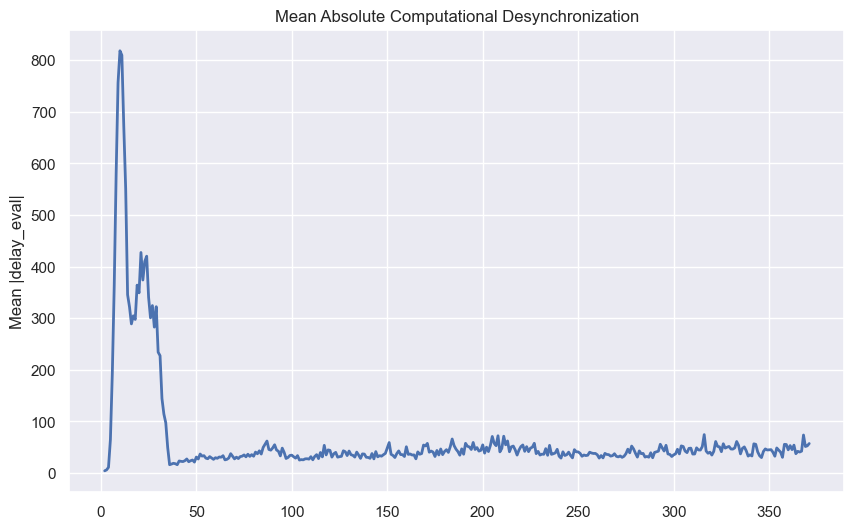

In [19]:
mean_abs_delay = (
    df.groupby("recv_step")["delay_eval"]
      .apply(lambda x: x.abs().mean())
)

plt.figure(figsize=(10, 6))

plt.plot(
    mean_abs_delay.index,
    mean_abs_delay.values,
    linewidth=2,
    label="Mean computational delay"
)

plt.ylabel("Mean |delay_eval|")
plt.title("Mean Absolute Computational Desynchronization")

In [18]:
mean_abs_delay

recv_step
2        4.277228
3        6.052632
4       11.042071
5       64.902013
6      193.066256
          ...    
367     42.356164
368     73.633803
369     51.388889
370     52.682171
371     57.142857
Name: delay_eval, Length: 370, dtype: float64

In [9]:
heatmap = df.pivot_table(
    values="delay_eval",
    index="from_island",
    columns="to_island",
    aggfunc="mean"
)

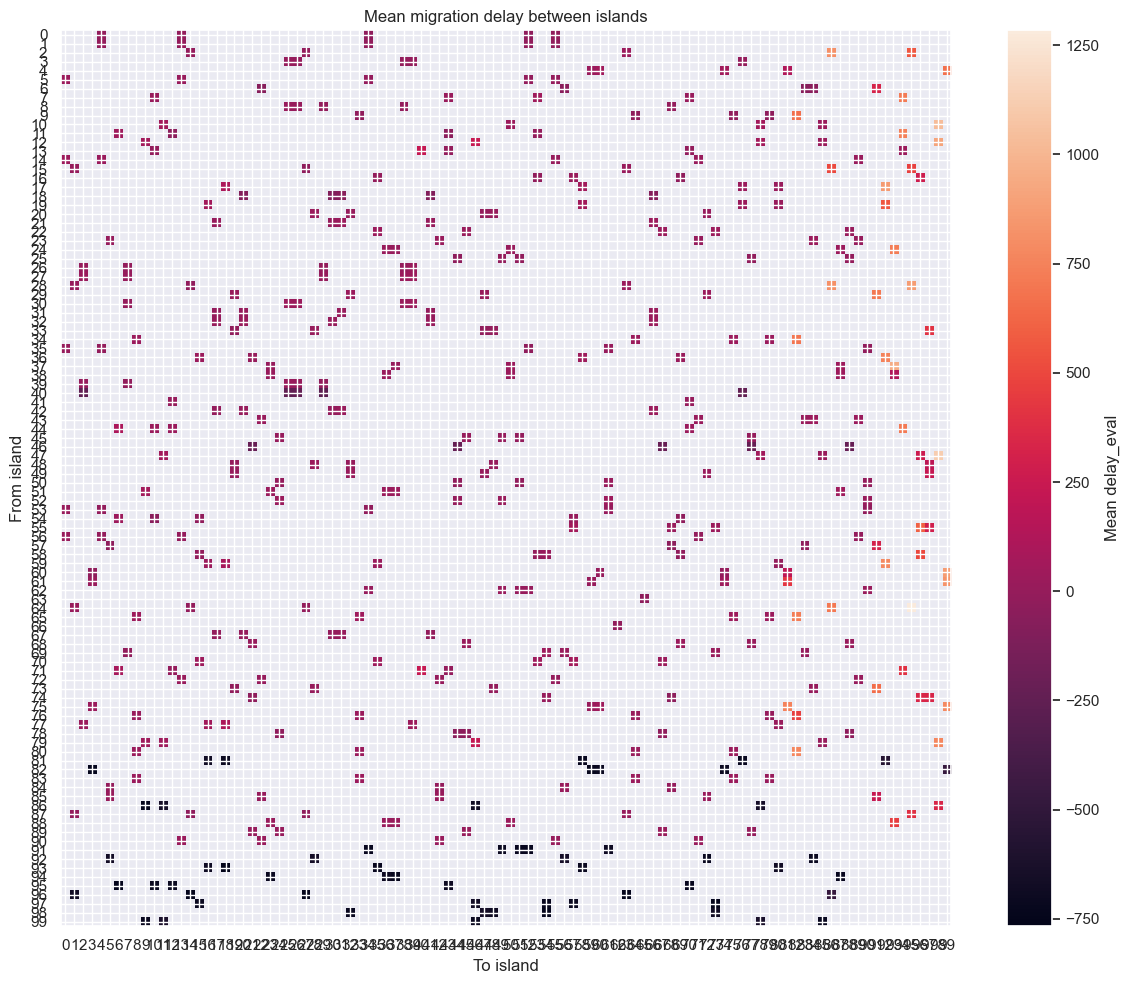

In [10]:
plt.figure(figsize=(12, 10))

im = plt.imshow(heatmap, aspect='auto')

plt.colorbar(im, label="Mean delay_eval")

plt.xlabel("To island")
plt.ylabel("From island")
plt.title("Mean migration delay between islands")

plt.xticks(np.arange(len(heatmap.columns)), heatmap.columns)
plt.yticks(np.arange(len(heatmap.index)), heatmap.index)

plt.tight_layout()
plt.show()